In [44]:
# Lasso Regularisation
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [29]:
insurance_data=pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=False,dtype=int)

X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

X["age_smoker"]=X["age"]*X["smoker"]
X["bmi_smoker"]=X["bmi"]*X["smoker"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

MSE for alpha=0.001 :  20922596.528006196
MSE for alpha=0.1 :  20921899.287567735
MSE for alpha=1 :  20915761.347724438
MSE for alpha=2 :  20909904.882848237
MSE for alpha=5 :  20894930.887387138
MSE for alpha=10 :  20879460.42907431
MSE for alpha=20 :  20885116.38537385
MSE for alpha=30 :  20939554.097556517
MSE for alpha=40 :  21030365.003757376
MSE for alpha=50 :  21137371.39625106
MSE for alpha=100 :  22325946.521791272


<Axes: >

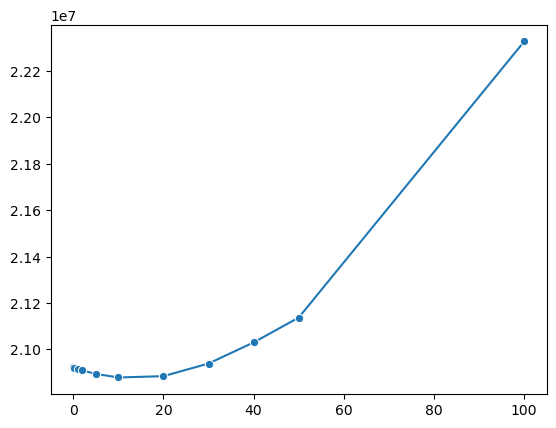

In [37]:
import seaborn as sns

alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]

for a in alphas:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)

    y_pred=lasso_model.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
    print(f"MSE for alpha={a} : ",mse)
    mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker="o")


In [45]:
#Cross validation

from sklearn.linear_model import LassoCV

a=[0.001,0.1,1,2,5,10,20,30,40,50,100]

lasso_cv_model=LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train,y_train)
print("Best alpha value:",lasso_cv_model.alpha_)

y_pred=lasso_cv_model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
print("Mse:",mse)
r2=r2_score(y_test,y_pred)
print("R2 Score : ",r2)

Best alpha value: 0.001
Mse: 20922596.528006196
R2 Score :  0.8652317714485489
